Diffusion
=========

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Diffusion profile

~~&sigma;<sub>diffusion</sub>(T<sub>Drift</sub>) = &Sqrt;(2&times;&sigma;<sub>diffusion</sub>&times;T<sub>Drift</sub>)~~

TODO: quote the right formula

### ICARUS

- longitudinal: 4.0&times;10<sup>-9</sup> cm<sup>2</sup>/ns
- transverse: 8.8&times;10<sup>-9</sup> cm<sup>2</sup>/ns

### GAMPixPy

- longitudinal: 6.627023218939979&times;10<sup>-6</sup> cm<sup>2</sup>/µs
- transverse: 1.323997803506287&times;10<sup>-5</sup> cm<sup>2</sup>/µs

In [2]:
def diffusion(d, Di, E, mu):
    
    e = 1
    return np.sqrt(2*e*Di*d/(mu*E))

In [3]:
# unit: mm/µs
vel_drift = 1.6

In [4]:
dLong = 6.6e-6
dTrans = 1.3e-5

In [5]:
mu_dune = 309.4939e-6 #cm2/V/µs

In [6]:
mu_gammatpc = 197.6811e-6 #cm2/V/µs

In [7]:
E = 500

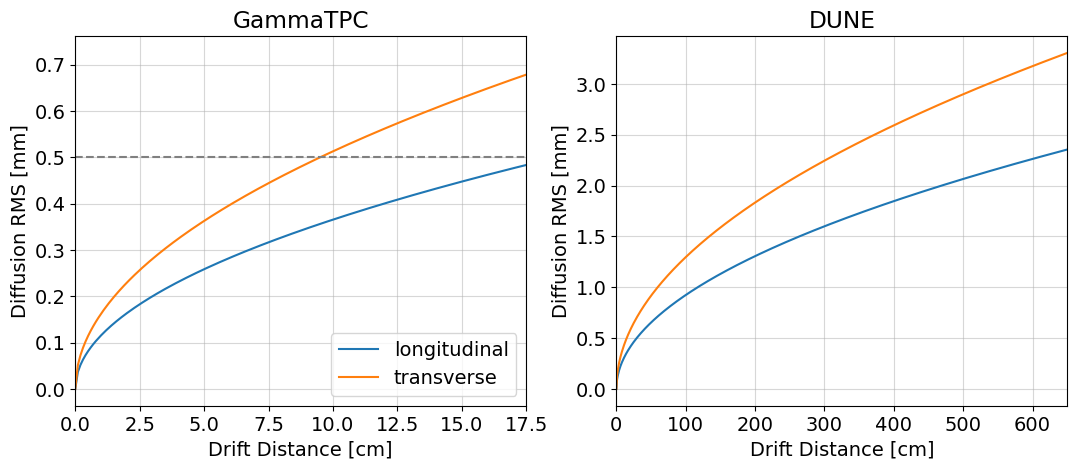

In [10]:
plt.rcParams.update({"font.size": 14,                     
                     "axes.labelsize": 14,
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,})

fig, ax = plt.subplots(1, 2, figsize = (12.8, 4.8))

ddune = np.linspace(0, 650, 651)
dgammatpc = np.linspace(0, 20, 201)

ax[0].plot(dgammatpc, diffusion(dgammatpc, dLong, E, mu_gammatpc)*10, label = 'longitudinal')
ax[0].plot(dgammatpc, diffusion(dgammatpc, dTrans, E, mu_gammatpc)*10, label = 'transverse')

ax[1].plot(ddune, diffusion(ddune, dLong, E, mu_dune)*10)
ax[1].plot(ddune, diffusion(ddune, dTrans, E, mu_dune)*10)

for i in range(2):
    ax[i].set_xlabel('Drift Distance [cm]')
    ax[i].set_ylabel('Diffusion RMS [mm]')
    ax[i].grid(alpha = 0.5)

ax[0].set_xlim([0, 17.5])
ax[1].set_xlim([0, 650])

ax[0].set_title('GammaTPC')
ax[1].set_title('DUNE')

ax[0].axhline(0.5, color = "gray", linestyle = "--")

ax[0].legend(loc = 'lower right')